<h1><center>K-Means Clustering</center></h1>

In this Notebook, I use K-means for Instagram visit clustering. This dataset captures Instagram users' visit scores and their spending rank (on a scale of 0 to 100). The goal is to analyze and group users into distinct clusters based on their behaviors, enabling insights into user engagement and spending potential. The dataset is suitable for unsupervised machine learning techniques like K-Means clustering.

Link to download the dataset: https://www.kaggle.com/datasets/mitgandhi10/dataset-for-kmeans-clustering

First import the required libraries.

In [106]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Import the dataset and print the first 5 rows out

In [107]:
dataset = pd.read_csv('Instagram visits clustering.csv')
dataset.head()

,User ID,Instagram visit score,Spending_rank(0 to 100)
0,0,63,24.050708
1,1,61,25.223290
2,2,104,18.528245
3,3,82,86.890232
4,4,14,31.492397


Print the names of all columns

In [108]:
dataset.columns

Index(['User ID', 'Instagram visit score', 'Spending_rank(0 to 100)'], dtype='object')

#### Pre-processing
Initialize x with 2 columns from dataset and convert to array

In [109]:
x = dataset[['Instagram visit score','Spending_rank(0 to 100)']].values
np.asarray(x).astype(float)
print(x.shape)
print(x[0:5])

(2600, 2)
[[ 63.          24.05070845]
 [ 61.          25.22329005]
 [104.          18.52824526]
 [ 82.          86.89023241]
 [ 14.          31.49239692]]


Display the scatter plot of the data

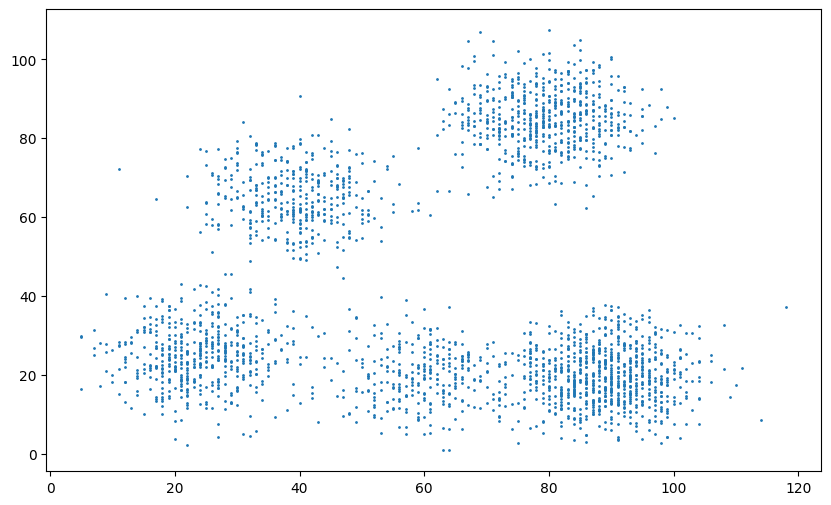

In [110]:
plt.figure(figsize=(10, 6))
plt.scatter(x[:, 0], [x[:,1]], s=1)

#### Setting up K-Means
- n_clusters: the number of clusters to form as well as the number of centroids to generate

Initialize with this parameter, output is called kmeans. Then fit the KMeans model with the feature x

In [111]:
num_cluster = 5
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=num_cluster, random_state=0)
kmeans.fit(x)

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


Get the coordinates of the cluster centers using KMeans .cluster_centers_

In [112]:
print(kmeans.cluster_centers_)

[[84.1465798  89.05345844]
 [83.24342746 19.87248561]
 [39.29323308 65.12865446]
 [27.29668412 24.30911866]
 [74.82312925 80.75492427]]


In [113]:
# kmeans.predict(x)

In [114]:
# kmeans.transform(x_test)

In [115]:
kmeans.inertia_

416977.54719241423

#### Creating the Visual Plot

Plot them and see what is look like

In [116]:
def plot_data(x):
    plt.plot(x[:, 0], x[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=35, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=35, linewidths=12,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, x, resolution=1000, show_centroids=True):
    mins = x.min(axis=0) - 0.1
    maxs = x.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    z = z.reshape(xx.shape)

    plt.contourf(z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(x)
    plot_centroids(clusterer.cluster_centers_)

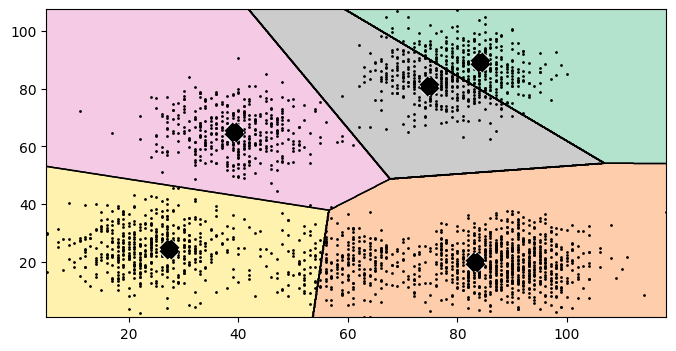

In [117]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, x)

Try with another parameters:
init: initialization method of the centroids
n_init: Number of time the k-means algorithm will be run with different centroid seeds. The final results will be the best output of n_init consecutive runs in terms of inertia.


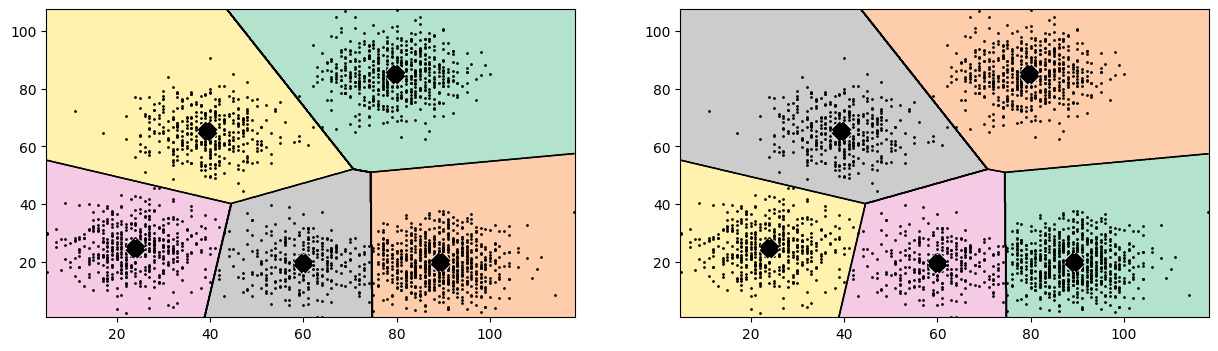

In [124]:
kmeans_rnd_init1 = KMeans(n_clusters=5, init="k-means++", n_init=1, random_state=2)
kmeans_rnd_init1.fit(x)
kmeans_rnd_init2 = KMeans(n_clusters=5, init="random", n_init=5, random_state=42)
kmeans_rnd_init2.fit(x)
plt.figure(figsize=(15,4))
plt.subplot(121)
plot_decision_boundaries(kmeans_rnd_init1, x)
plt.subplot(122)
plot_decision_boundaries(kmeans_rnd_init2, x)

#### Inertia
Sum of squared distances of samples to their closest cluster center, weighted by the sample weights if provided

In [119]:
print(kmeans_rnd_init1.inertia_)
print(kmeans_rnd_init2.inertia_)

416936.2213758706
278407.52457196836


Try with another n_cluster

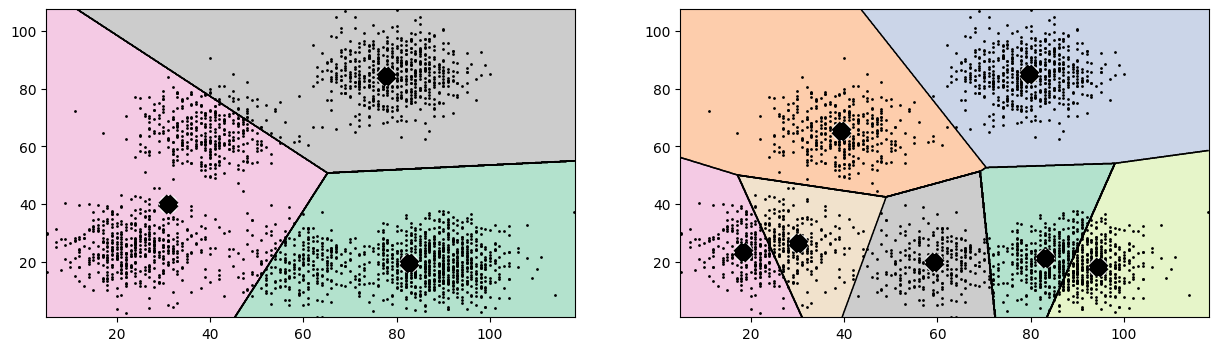

In [120]:
kmeans_k3 = KMeans(n_clusters=3, random_state=42)
kmeans_k7 = KMeans(n_clusters=7, random_state=42)
kmeans_k3.fit(x)
kmeans_k7.fit(x)
plt.figure(figsize=(15,4))
plt.subplot(121)
plot_decision_boundaries(kmeans_k3, x)
plt.subplot(122)
plot_decision_boundaries(kmeans_k7, x)

In [121]:
print(kmeans_k3.inertia_)
print(kmeans_k7.inertia_)

847082.7695259259
234435.11529225437
